[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Real-Time Video Captioning on Egocentric Video**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

Run the local Moondream VLM model on video(especially egocentric). The setup cell starts the local Ollama service when needed, downloads the configured model, and optionally warms it so the first real image/video.

## 1. Configure Inputs

Change these paths and prompts, then run the notebook top to bottom. The defaults use the sample files already present in this repository.

In [5]:
from __future__ import annotations

from pathlib import Path

MODEL_NAME = "moondream"

IMAGE_PATH = Path("test_image.jpg")
IMAGE_PROMPT = "Describe this image in one concise paragraph."

VIDEO_PATH = Path("video\\pov_dog_walking.mp4")
VIDEO_PROMPT = "Describe what is happening in this scene."
INTERVAL_SECONDS = 2.0
SAVE_VIDEO_PATH = Path("result/notebook_captioned_dog_walking.mp4")
OUTPUT_JSON_PATH = Path("result/notebook_video_result.json")

WEBCAM_INPUT = "0"
WEBCAM_PROMPT = "Describe what the camera is seeing."
WEBCAM_INTERVAL_SECONDS = 2.0

## 2. Python Dependencies

Run this before importing the runner. It installs any missing Python packages into the active notebook kernel.

In [6]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "ollama": "ollama",
    "PIL": "pillow",
    "tqdm": "tqdm",
    "IPython": "ipython",
}

missing_packages = [
    package
    for module_name, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("Python dependencies are already installed.")

Python dependencies are already installed.


## 3. Imports And Ollama Startup

This cell imports the runner functions directly and defines notebook helpers for starting Ollama, pulling the model, and saving structured outputs.

In [7]:
import json
import os
import shutil
import subprocess
import time
from typing import Any

import ollama
from IPython.display import Image as NotebookImage
from IPython.display import JSON, Video, display

from moondream_runner import (
    analyze_image,
    analyze_video,
    analyze_webcam,
    get_model_processor_status,
)


def _get_field(obj: Any, key: str, default: Any = None) -> Any:
    if isinstance(obj, dict):
        return obj.get(key, default)
    return getattr(obj, key, default)


def _model_names(response: Any) -> list[str]:
    models = _get_field(response, "models", [])
    names: list[str] = []
    for model in models:
        name = _get_field(model, "model") or _get_field(model, "name")
        if name:
            names.append(str(name))
    return names


def ollama_is_running() -> bool:
    try:
        ollama.list()
        return True
    except Exception:
        return False


def start_ollama_server(timeout: int = 45) -> subprocess.Popen | None:
    if ollama_is_running():
        print("Ollama service is already running.")
        return None

    executable = shutil.which("ollama")
    if not executable:
        raise RuntimeError(
            "Could not find the 'ollama' executable on PATH. Install Ollama or start the Ollama app, then rerun this cell."
        )

    log_path = Path("ollama_server.log")
    log_file = log_path.open("a", encoding="utf-8")
    process = subprocess.Popen(
        [executable, "serve"],
        stdout=log_file,
        stderr=subprocess.STDOUT,
        start_new_session=True,
    )
    process._moondream_log_file = log_file

    deadline = time.time() + timeout
    while time.time() < deadline:
        if ollama_is_running():
            print(f"Started Ollama service. Logs: {log_path}")
            return process
        if process.poll() is not None:
            log_file.close()
            raise RuntimeError(f"'ollama serve' exited early. Check {log_path} for details.")
        time.sleep(1)

    raise TimeoutError(f"Timed out waiting for Ollama to start. Check {log_path} for details.")


def model_is_available(model_name: str) -> bool:
    wanted = model_name.lower()
    return any(wanted in name.lower() for name in _model_names(ollama.list()))


def pull_model_if_needed(model_name: str) -> None:
    if model_is_available(model_name):
        print(f"Model '{model_name}' is already available.")
        return

    print(f"Pulling Ollama model '{model_name}'. This can take a while the first time...")
    last_line = None
    for progress in ollama.pull(model_name, stream=True):
        status = _get_field(progress, "status", "")
        total = _get_field(progress, "total", 0) or 0
        completed = _get_field(progress, "completed", 0) or 0
        if total:
            line = f"{status}: {completed / total * 100:5.1f}%"
        else:
            line = str(status)
        if line and line != last_line:
            print(line)
            last_line = line


def warm_model(model_name: str, keep_alive: str = "10m") -> None:
    try:
        ollama.chat(
            model=model_name,
            messages=[{"role": "user", "content": "Reply with OK."}],
            keep_alive=keep_alive,
            options={"num_predict": 1},
        )
        print(f"Model '{model_name}' is loaded and will be kept alive for {keep_alive}.")
    except Exception as exc:
        print(f"Model was pulled, but text warm-up was skipped: {exc}")
        print("The first image or video analysis call will load it instead.")


def ensure_ollama_ready(model_name: str = MODEL_NAME, keep_alive: str = "10m") -> subprocess.Popen | None:
    process = start_ollama_server()
    pull_model_if_needed(model_name)
    warm_model(model_name, keep_alive=keep_alive)
    return process


def save_results(results: dict[str, Any], output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(results, indent=4, ensure_ascii=False), encoding="utf-8")
    return output_path

## 4. Start Ollama And Prepare The Model

Run this once per notebook session. It starts `ollama serve` if the service is not already reachable, pulls `moondream` if missing, and performs a small warm-up request.

In [8]:
ollama_process = ensure_ollama_ready(MODEL_NAME)
get_model_processor_status(MODEL_NAME)

Ollama service is already running.
Model 'moondream' is already available.
Model 'moondream' is loaded and will be kept alive for 10m.


'100% GPU (VRAM: 1.23 GB)'

## 5. Image Analysis

This calls `analyze_image(...)` directly from `moondream_runner.py`.

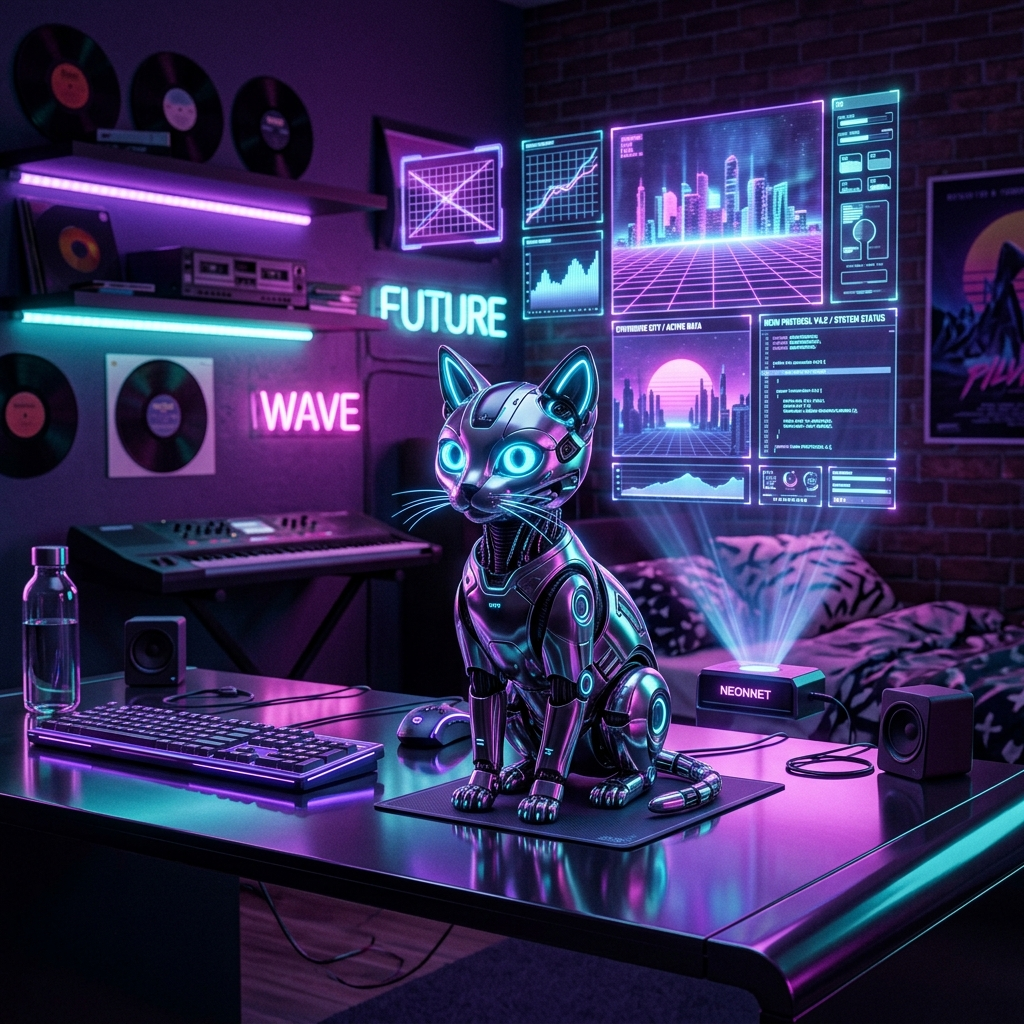

[Info] Analyzing image: 'test_image.jpg'
[Info] Prompt: 'Describe this image in one concise paragraph.'

[Info] Model hardware device: 100% GPU (VRAM: 1.23 GB)

--- Analysis Result ---

 A futuristic room features a black desk with a computer setup, including a keyboard and mouse, accompanied by a cat statue of a robot sitting on the desk. The walls are adorned with neon signs and posters, creating an atmosphere of technological innovation and creativity.
-----------------------



<IPython.core.display.JSON object>

In [9]:
display(NotebookImage(filename=str(IMAGE_PATH)))

image_result = analyze_image(
    image_path=str(IMAGE_PATH),
    prompt=IMAGE_PROMPT,
    model_name=MODEL_NAME,
)

display(JSON(image_result))

## 6. Video Analysis And Captioned Export

This calls `analyze_video(...)` directly, samples frames every `INTERVAL_SECONDS`, and writes a captioned MP4 to `SAVE_VIDEO_PATH`.

In [10]:
SAVE_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)

video_result = analyze_video(
    video_path=str(VIDEO_PATH),
    prompt=VIDEO_PROMPT,
    interval=INTERVAL_SECONDS,
    model_name=MODEL_NAME,
    save_video_path=str(SAVE_VIDEO_PATH),
)

display(JSON(video_result))
display(Video(str(SAVE_VIDEO_PATH), embed=False))

[Info] Video duration: 13.88s | FPS: 29.97 | Total Frames: 416
[Info] Sampling interval: every 2.00 second(s)
[Info] Prompt per frame: 'Describe what is happening in this scene.'

[Info] Processing 8 frames...


Captioning video frames:  12%|█▎        | 1/8 [00:01<00:07,  1.05s/frame, Time: 00:00:00]


[Info] Model hardware device: 100% GPU (VRAM: 1.23 GB)


Captioning video frames: 100%|██████████| 8/8 [00:08<00:00,  1.10s/frame, Time: 00:00:13]



=== Sequential Video Analysis Timeline ===
[00:00:00] In the image, a person wearing a blue shirt and yellow wristband is walking their dog on a leash through a grassy field. The person's hand can be seen holding onto the leash as they walk alongside their furry companion.
[00:00:01] In the image, a person wearing a blue and yellow wristband is holding onto a dog's collar while walking on grass. The dog appears to be enjoying the walk with its owner. The scene captures a moment of bonding between the person and their canine companion as they explore the outdoors together.
[00:00:03] In the image, a person's hand is holding onto a leash attached to a dog that is standing on grass. The dog appears to be looking up at its owner with anticipation and excitement. The scene captures a moment of bonding between the pet owner and their canine companion as they enjoy each other's company outdoors.

The background features a lush green field, providing an ideal setting for this outdoor activity

Writing output video: 100%|██████████| 416/416 [00:28<00:00, 14.42frame/s]

[Success] Captioned video successfully saved to 'result\notebook_captioned_dog_walking.mp4'



<IPython.core.display.JSON object>

## 7. Save Structured Results

Save the most recent video timeline as JSON for reuse outside the notebook.

In [ ]:
saved_path = save_results(video_result, OUTPUT_JSON_PATH)
saved_path

## 8. Optional Webcam Mode

Uncomment and run this cell only when you want the interactive OpenCV webcam window. Press `q` in the OpenCV window to stop.

In [12]:
webcam_result = analyze_webcam(
    camera_input=WEBCAM_INPUT,
    prompt=WEBCAM_PROMPT,
    interval=WEBCAM_INTERVAL_SECONDS,
    model_name=MODEL_NAME,
    save_video_path=str(SAVE_VIDEO_PATH.parent / "webcam_output.mp4"),
)
# display(JSON(webcam_result))

[Info] Webcam resolution: 640x480 | Target FPS: 30.0
[Info] Auto-caption interval: every 2.00 second(s)
[Info] Prompt: 'Describe what the camera is seeing.'
[Info] Controls: Press 'q' to exit, 'c' to caption now, 's' to toggle auto-caption.

[Info] Saving recorded stream with HUD overlays to 'result\webcam_output.mp4'...
[17:22:58] The image shows a man wearing glasses and a striped shirt sitting in front of a window, with his face partially visible as he looks directly at the camera. The room appears to be an office or workspace, as there are two chairs present - one near the left side of the frame and another on the right side. 

In addition to these elements, there is also a TV mounted on the wall in the background, which could potentially be used for presentations or meetings. (4.08s)
[17:22:59] The image shows a man wearing glasses and earphones, sitting in an office setting with a TV mounted on the wall behind him. The man appears to be focused or engaged in some activity while w

[17:23:15] The image shows a man wearing glasses and earphones, sitting in an office setting with a chair behind him. The man appears to be focused on something outside of the frame, possibly engaged in work or a task that requires his attention. (0.48s)


---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
